# 多元线性回归-学习率

这一节用房价数据对比不同学习率对梯度下降的影响。

## 1. 梯度下降和学习率

![梯度下降的数学原理](image/04_learning_rate_1.png)

![学习率大小对训练路径的影响](image/04_learning_rate_2.png)

In [11]:
import numpy as np
import matplotlib.pyplot as plt


data = np.genfromtxt("data/data_house.csv", delimiter=",", skip_header=1)

X = data[:, :4]
y = data[:, 4]

mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0)
X_scaled = (X - mu) / sigma

print(f"样本数量: {X_scaled.shape[0]}")
print(f"特征数量: {X_scaled.shape[1]}")
print(f"缩放后特征均值: {X_scaled.mean(axis=0)}")
print(f"缩放后特征标准差: {X_scaled.std(axis=0)}")

样本数量: 1000
特征数量: 4
缩放后特征均值: [1.45905510e-15 1.38000722e-16 8.45989945e-17 1.19959598e-16]
缩放后特征标准差: [1. 1. 1. 1.]


In [12]:
def compute_cost(X, y, w, b):
    m = len(y)
    error = X @ w + b - y
    return np.sum(error ** 2) / (2 * m)


def gradient_descent(X, y, alpha, num_iters):
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0
    cost_history = []

    for _ in range(num_iters):
        error = X @ w + b - y
        dj_dw = X.T @ error / m
        dj_db = np.sum(error) / m

        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost_history.append(compute_cost(X, y, w, b))

    return w, b, cost_history

## 2. 合适的学习率是什么样

下面把太小、合适、太大的学习率放在一起比较。观察重点不是某一步下降得多快，而是代价函数是否稳定下降，以及最终是否到达较低的代价。

In [13]:
alpha_small = 0.001
alpha_good = 0.1
alpha_large = 2.0

_, _, cost_small = gradient_descent(X_scaled, y, alpha=alpha_small, num_iters=100)
_, _, cost_good = gradient_descent(X_scaled, y, alpha=alpha_good, num_iters=100)
_, _, cost_large = gradient_descent(X_scaled, y, alpha=alpha_large, num_iters=20)

print("学习率对比：")
print(f"太小 alpha={alpha_small}: 最终代价 {cost_small[-1]:.2f}")
print(f"合适 alpha={alpha_good}: 最终代价 {cost_good[-1]:.2f}")
print(f"太大 alpha={alpha_large}: 最终代价 {cost_large[-1]:.2f}")

学习率对比：
太小 alpha=0.001: 最终代价 43438.66
合适 alpha=0.1: 最终代价 57.85
太大 alpha=2.0: 最终代价 581204250216450818048.00


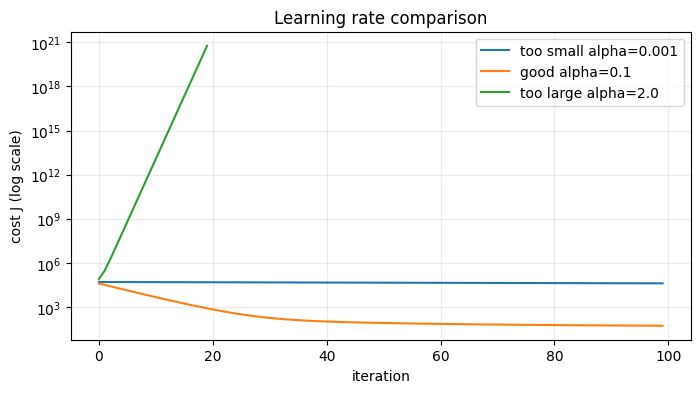

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(cost_small, label=f"too small alpha={alpha_small}")
plt.plot(cost_good, label=f"good alpha={alpha_good}")
plt.plot(range(len(cost_large)), cost_large, label=f"too large alpha={alpha_large}")
plt.yscale("log")
plt.xlabel("iteration")
plt.ylabel("cost J (log scale)")
plt.title("Learning rate comparison")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 3. 小结

| 学习率 | 现象 | 结果 |
| --- | --- | --- |
| 太小 | 每次只走一小步 | 稳定但训练慢 |
| 太大 | 每次步子太大 | 容易震荡或发散 |
| 合适 | 稳定且快速下降 | 更容易收敛到较低代价 |

实际训练时，通常需要尝试多个学习率，并观察代价函数是否持续下降。